In [1]:
import pathlib
import sys
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from seagliderOG1 import convertOG1, writers
from tqdm import tqdm
import xarray as xr
import importlib
import numpy as np
import matplotlib.dates as mdates
import yaml

script_dir = pathlib.Path().parent.absolute()
parent_dir = script_dir.parents[0]
sys.path.append(str(parent_dir))
from dissipationSML import reading, plotting, tools, interactive, utilities

In [2]:
importlib.reload(reading)
importlib.reload(plotting)
importlib.reload(tools)
importlib.reload(interactive)
plotting_style = '/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/plotting.mplstyle'

# 1. Choose a glider mission and load the dataset (OG1 format)

In [ ]:
# Example usage
yaml_path = str(parent_dir) + '/dissipationSML/glider_server.yaml'  # Update with your actual path
selected_glider = interactive.interactive_glider_selection(yaml_path)

Dropdown(description='Select Glider:', options=('005', '012', '014', '016', '101', '102', '103', '104', '105')…

Dropdown(description='Select Mission:', options=('06/08 (dives: 386)', '08/09 (dives: 464)', '11/08 (dives: 48…

Button(description='Confirm Selection', style=ButtonStyle())

Selected Path: https://www.ncei.noaa.gov/data/oceans/glider/seaglider/uw/005/20080606/


In [4]:
data_path = selected_glider['path']
end_profile = selected_glider['dives']
destination_folder = "/Users/tillmoritz/Desktop/Master_thesis/Data/Glider"
mission_path = destination_folder + '/' + selected_glider['glider'] + '/' + selected_glider['mission']

In [5]:
ds = xr.open_dataset(mission_path + '/all_data_OG1.nc')#

In [6]:
mld = tools.compute_mld(ds,'SIGMA_T',method = 'threshold', threshold=0.03, use_bins=True, binning = 5)
#mld = tools.compute_mld(ds,'SIGMA_1',method = 'CR', threshold=-2, use_bins=True, binning = 5)
importlib.reload(utilities)
mld_ds = utilities.df_to_ds(mld,folder = selected_glider['mission'],glider_name= selected_glider['glider'])

# 2. Calculate dissipation for the glider mission

### 2.1 High-pass filter the vertical velocity data, using a 4-th order butterworth filter

$w_{HP}$ is added to the dataset 

In [7]:
ds_filtered = tools.highpass_butterworth_time(ds, 'VERTICAL_WATER_VELOCITY', cutoff_period=330, order=4, max_interval=60)

Filtering VERTICAL_WATER_VELOCITY: 100%|██████████| 770/770 [00:25<00:00, 29.84it/s]


cut_offs = [200, 300, 400, 500]
HP_filtered_WW = []
for cut_off in cut_offs:
    ds_filtered = tools.highpass_butterworth_time(ds, 'VERTICAL_WATER_VELOCITY', cutoff_period=cut_off, order=4, max_interval=60)
    HP_filtered_WW.append(ds_filtered['VERTICAL_WATER_VELOCITY_HP'])

window_sizes = [75, 100, 150, 200,250,300]
velocity_scales = []
for window_size in window_sizes:
    ds_filtered = tools.add_velocity_scale(ds_filtered,window_size_seconds=window_size)
    velocity_scales.append(ds_filtered['VELOCITY_SCALE'])

for i, cut_off in enumerate(cut_offs):
    ### add the filtered data to the dataset
    ds_filtered[f'VERTICAL_WATER_VELOCITY_HP_{cut_off}'] = HP_filtered_WW[i]

for i, window_size in enumerate(window_sizes):
    ### add the filtered data to the dataset
    ds_filtered[f'VELOCITY_SCALE_{window_size}'] = velocity_scales[i]

importlib.reload(plotting)
vars = ['VERTICAL_WATER_VELOCITY_HP_200', 'VERTICAL_WATER_VELOCITY_HP_300','VERTICAL_WATER_VELOCITY_HP_400', 'VERTICAL_WATER_VELOCITY_HP_500']
vars = ['VELOCITY_SCALE_75', 'VELOCITY_SCALE_100', 'VELOCITY_SCALE_150', 'VELOCITY_SCALE_200', 'VELOCITY_SCALE_250', 'VELOCITY_SCALE_300']
fig, ax, images = plotting.plot_section(ds_filtered, vars, v_res=5)
### change the limits of the colormaps to the limits of the last one
clims = images[-1].get_clim()
images[0].set_clim(clims[0], clims[1])

interactive.interactive_profile(ds_filtered)

### 2.2 Add the velocity scale using the $w_{HP}$

In [8]:
ds_filtered = tools.add_velocity_scale(ds_filtered,window_size_seconds=120)

/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/tools.py:339: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  dims = list(ds.dims.keys())[0]
Processing profiles: 100%|██████████| 770/770 [00:01<00:00, 413.14it/s]


### 2.3 Bin all the profiles along vertical using mean depth-difference as the bin size for each profile

In [11]:
importlib.reload(utilities)
ds_binned = utilities.bin_all_profiles(ds_filtered,vars = ['VERTICAL_WATER_VELOCITY','DEPTH','PRES','TEMP','PSAL','LONGITUDE','LATITUDE','VERTICAL_WATER_VELOCITY_HP','VELOCITY_SCALE','VELOCITY_SCALE_2_LOG'], binning = None, dim = 'DEPTH',max_interval=20) 

KeyError: "['SIGTHETA', 'SIGMA_T'] not in index"

### 2.4 Add the adiabatically sorted $N_{2}$

In [77]:
ds_binned = tools.add_adiabatic_sorted_N2(ds_binned, plev=20)

Calculating adiabatic N² for 594 profiles...


/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/tools.py:217: RuntimeWarning: Mean of empty slice
  rhobar = np.nanmean(rho[icyc])
/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/tools.py:259: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  dims = list(ds.dims.keys())[0]


### 2.5 Add the dissipation estimates using the Large Eddy Method (LEM)  $e = c_{\epsilon} N (q')^{2}$

In [198]:
importlib.reload(plotting)
bg_yaml_path = '/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/bg_dissipation.yaml'
with open(bg_yaml_path, 'r') as file:
    bg_yaml = yaml.safe_load(file)

In [199]:
### Extract the c value from the bg_yaml
Glider = ds_binned.attrs['Glider']
Mission = ds_binned.attrs['Mission']

faktor = bg_yaml['sg'+ Glider][Glider+'/'+Mission]['faktor']
c = faktor * 0.37
print(f'c value for {Glider}/{Mission}: {c}')

c value for 012/20070831: 0.296


In [200]:
importlib.reload(tools)
c = bg_yaml['sg'+ Glider][Glider+'/'+Mission]['c']
ds_binned = tools.LEM_dissipation(ds_binned,c = c)

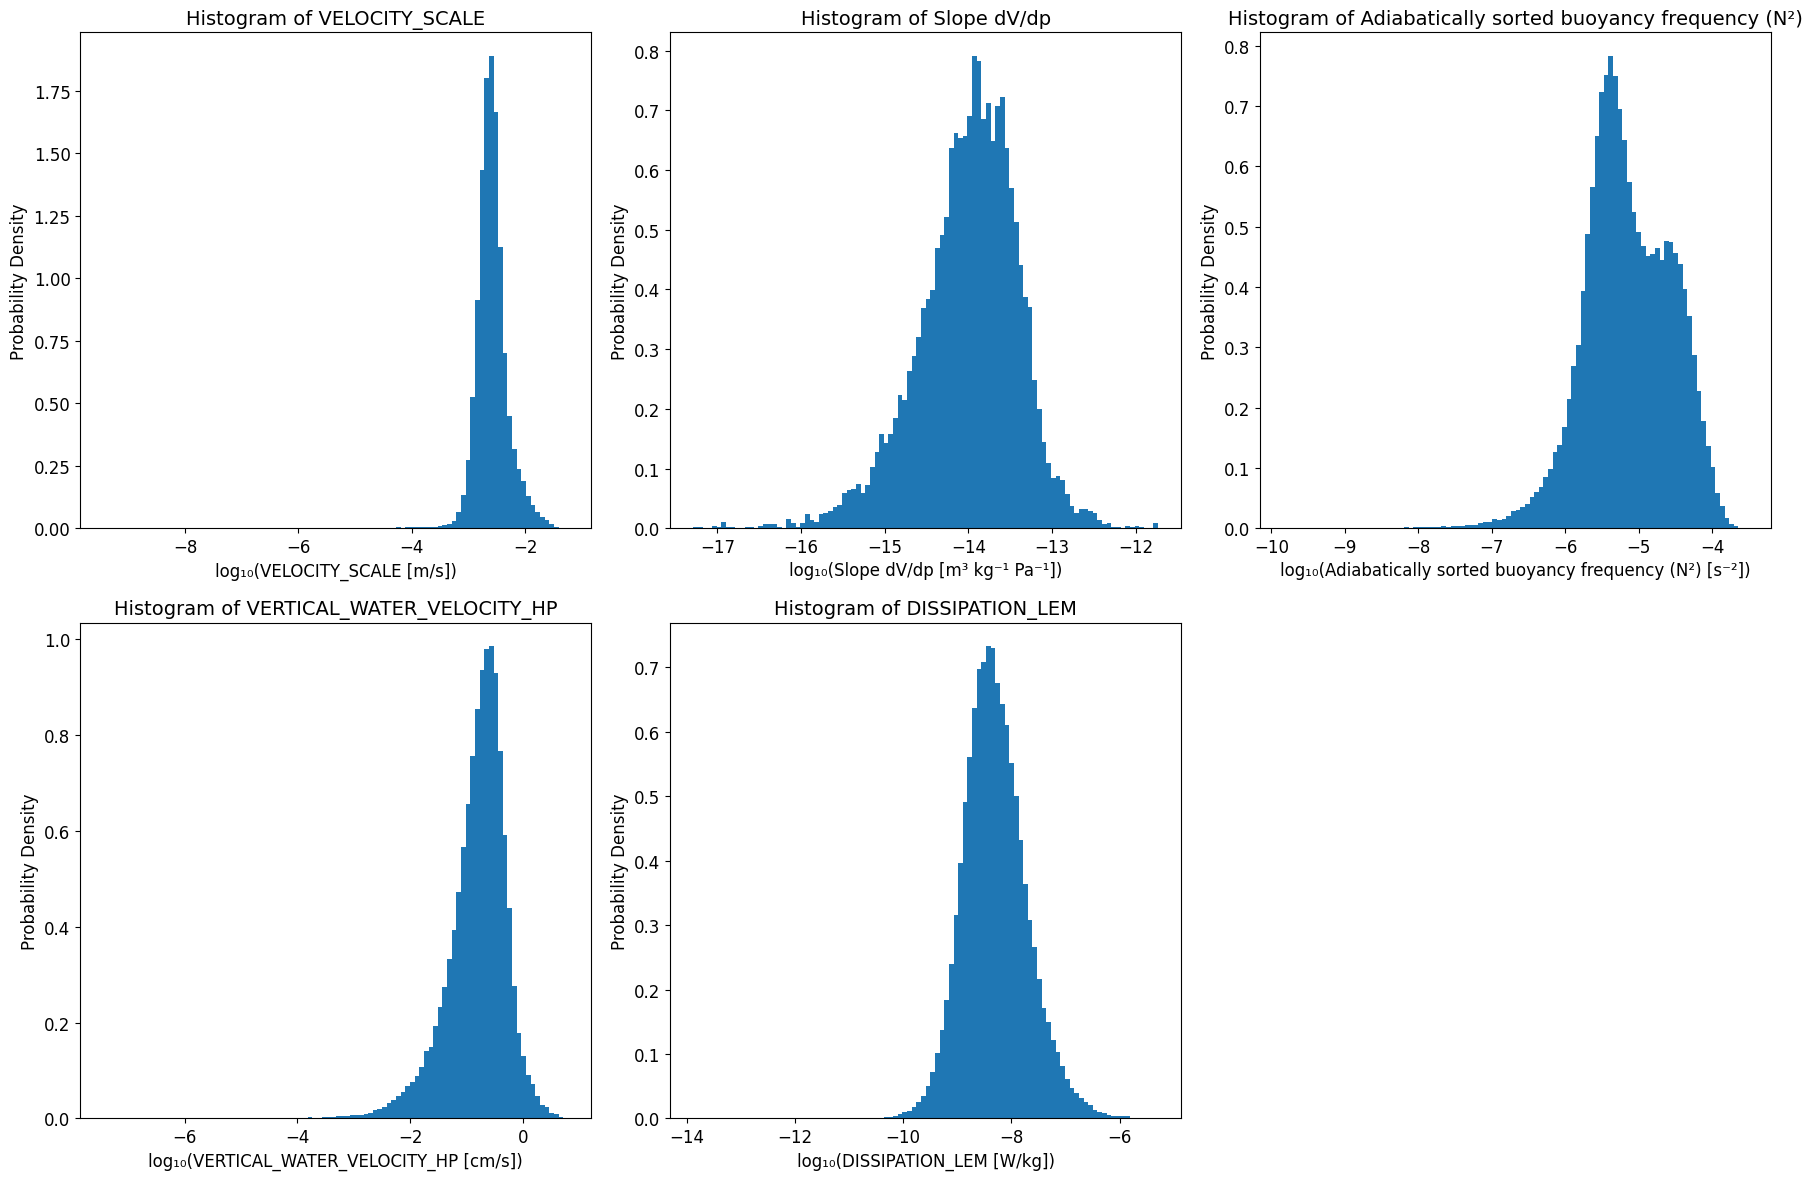

In [194]:
importlib.reload(plotting)
fig, axes = plotting.plot_histogram(ds_binned, vars=['VELOCITY_SCALE','ALPHA_1','SORTED_N2','VERTICAL_WATER_VELOCITY_HP','DISSIPATION_LEM'], bins=100, log_scale=True, density=True)
plt.show()

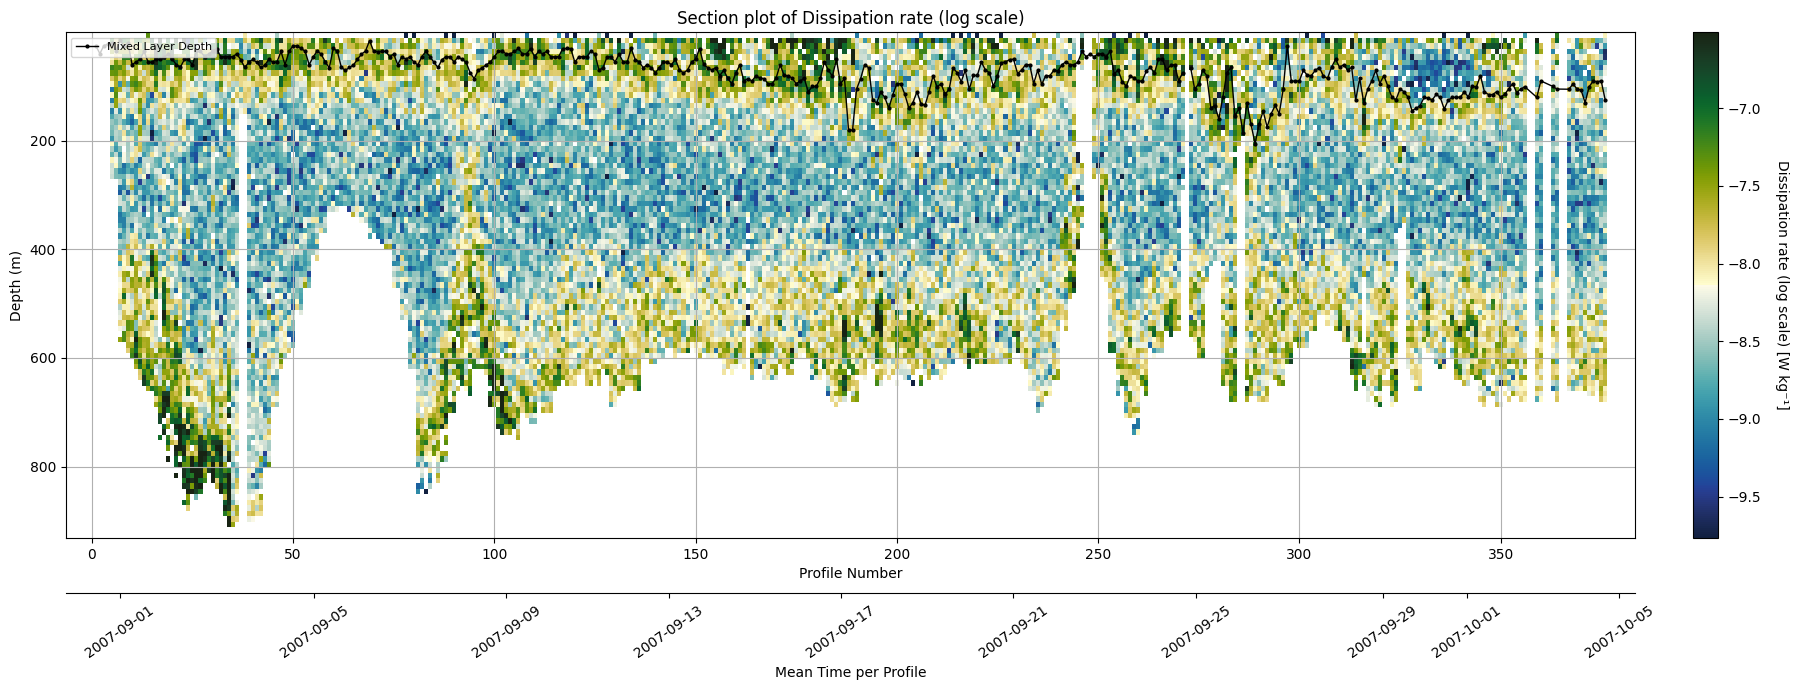

In [185]:
importlib.reload(plotting)
importlib.reload(utilities)
start = 450
end = 600
start = None
end = None
#fig, axs = plotting.plot_section(ds_binned, vars=['SORTED_N2','VELOCITY_SCALE_2_LOG','DISSIPATION_LEM_LOG'], v_res=10, start=start, end=end, mld_df = mld)
fig, axs = plotting.plot_section(ds_binned, vars=['DISSIPATION_LEM_LOG'], v_res=10, start=start, end=end, mld_df = mld)

In [181]:
### load sg005 mission 20080606 as it is the only mission verified using Microstructure profile
sg005_mission = destination_folder + '/005/20080606'
sg005_ds = xr.open_dataset(sg005_mission + '/dissipation_binned.nc')

In [182]:
def get_background_dissipation(ds, profile_range=[0, -1], depth_range=[200, 400], sg005_ds=None):
    """
    Calculate the background dissipation from the dataset and optionally compare with sg005_ds.
    
    Parameters:
    - ds: xarray Dataset
    - profile_range: List [start, end] of profile numbers
    - depth_range: List [min_depth, max_depth]
    - sg005_ds: Optional xarray Dataset to compare
    
    Returns:
    - Tuple: (background_sg005, ds_background) if sg005_ds provided, else (None, ds_background)
    """
    
    def cut_background(ds, profile_range, depth_range):
        return ds.where(
            (ds.PROFILE_NUMBER >= profile_range[0]) &
            (ds.PROFILE_NUMBER <= profile_range[1]) &
            (ds.DEPTH >= depth_range[0]) &
            (ds.DEPTH <= depth_range[1]),
            drop=True
        )

    def plot_hist(ax, ds, median=None, mean=None, color='blue'):
        figh, axh = plotting.plot_histogram(
            ds, vars=['DISSIPATION_LEM'], bins=50, log_scale=True, density=True,
            alpha=0.2, color=color, edgecolor='black', ax=ax
        )
        unit = utilities.get_unit(ds, 'DISSIPATION_LEM')
        if mean is not None:
            ax.axvline(np.log10(mean), color=color, linestyle='--', label=f'Mean = {mean:.2e} [{unit}]')
        if median is not None:
            ax.axvline(np.log10(median), color=color, linestyle=':', label=f'Median = {median:.2e} [{unit}]')
        ax.set_title(f'Background Dissipation Histogram of sg{ds.Glider +'/'+ ds.Mission} (c = {ds.c_epsilon})')
        ax.legend()
        return ax

    ds_background = cut_background(ds, profile_range, depth_range)
    mean_bg = np.nanmean(ds_background['DISSIPATION_LEM'].values)
    median_bg = np.nanmedian(ds_background['DISSIPATION_LEM'].values)

    background_sg005 = None

    mean_ratio, median_ratio, ratio_total = None, None, None

    if sg005_ds is None:
        # Just one histogram
        fig, ax = plt.subplots(figsize=(8, 5))
        plot_hist(ax, ds_background, median_bg, mean_bg, color='blue', label='Background')
    else:
        # Load ranges and cut sg005 dataset
        profile_range_005 = bg_yaml['sg005']['005/20080606']['profile_range']
        depth_range_005 = bg_yaml['sg005']['005/20080606']['depth_range']
        background_sg005 = cut_background(sg005_ds, profile_range_005, depth_range_005)

        mean_005 = np.nanmean(background_sg005['DISSIPATION_LEM'].values)
        median_005 = np.nanmedian(background_sg005['DISSIPATION_LEM'].values)

        # Create combined figure with 3 subplots
        fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

        # Subplot 1: original dataset
        axs[0].set_title(f'Background Dissipation Histogram of {ds.id.split("T")[0]} (c = {ds.c_epsilon})')
        plot_hist(axs[0], ds_background, median_bg, mean_bg, color='blue')

        # Subplot 2: sg005 dataset
        axs[1].set_title(f'Background Dissipation Histogram of {sg005_ds.id.split("T")[0]} (c = {sg005_ds.c_epsilon})')
        plot_hist(axs[1], background_sg005, median_005, mean_005, color='red')

        # Subplot 3: comparison
        plotting.plot_histogram(ds_background, vars=['DISSIPATION_LEM'], bins=50, log_scale=True, density=True,
                                 alpha=0.2, color='blue', edgecolor='darkblue', ax=axs[2])
        plotting.plot_histogram(background_sg005, vars=['DISSIPATION_LEM'], bins=50, log_scale=True, density=True,
                                 alpha=0.2, color='red', edgecolor='darkred', ax=axs[2])
        axs[2].set_title('Comparison of Background Dissipation Histograms')
        axs[2].legend(['sg' + ds_background.Glider + '/' + ds_background.Mission, 'sg005/20080606'])

        c_005 = bg_yaml['sg005']['005/20080606']['c']
        mean_ratio = mean_005 / mean_bg
        c_mean = c_005 * mean_ratio
        median_ratio = median_005 / median_bg
        c_median = c_005 * median_ratio
        ratio_total = (mean_ratio + median_ratio) / 2
        c_total = c_005 * ratio_total

        print(f'Mean ratio (sg005/Background): {mean_ratio:.3f}, c = {c_mean:.3f}')
        print(f'Median ratio (sg005/Background): {median_ratio:.3f}, c = {c_median:.3f}')
        print(f'Average ratio (sg005/Background): {ratio_total:.3f}, c = {c_total:.3f}')

    # Show section plot
    figs, section_axs = plotting.plot_section(ds_background, vars=['SORTED_N2', 'VELOCITY_SCALE_2_LOG', 'DISSIPATION_LEM_LOG'], v_res=2)
    plt.show()

    return mean_ratio, median_ratio, ratio_total


In [183]:
### get depth_range and profile_range from yaml
bg_yaml_path = '/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/bg_dissipation.yaml'
with open(bg_yaml_path, 'r') as file:
    bg_yaml = yaml.safe_load(file)
profile_range = bg_yaml['sg'+ Glider][Glider+'/'+Mission]['profile_range']
depth_range = bg_yaml['sg'+ Glider][Glider+'/'+Mission]['depth_range']

print(f'Profile Range: {profile_range}, Depth Range: {depth_range}')

Profile Range: [40, 90], Depth Range: [200, 500]


Mean ratio (sg005/Background): 0.940, c = 0.348
Median ratio (sg005/Background): 0.988, c = 0.366
Average ratio (sg005/Background): 0.964, c = 0.357


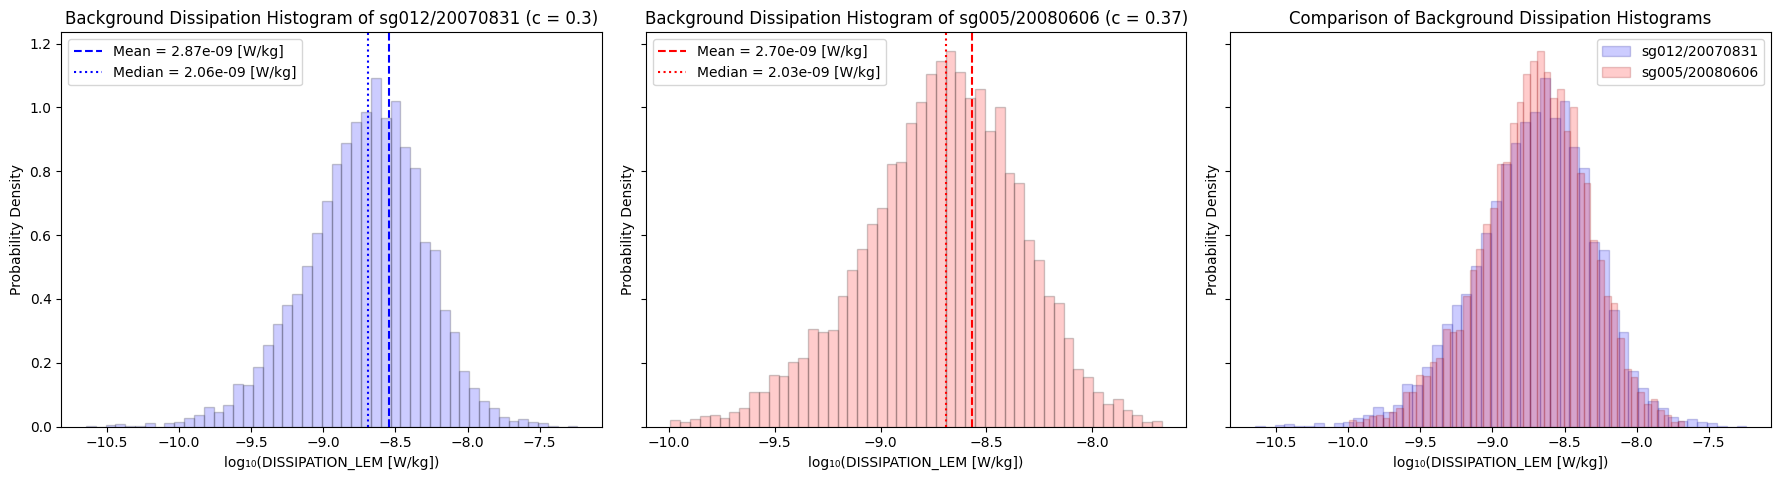

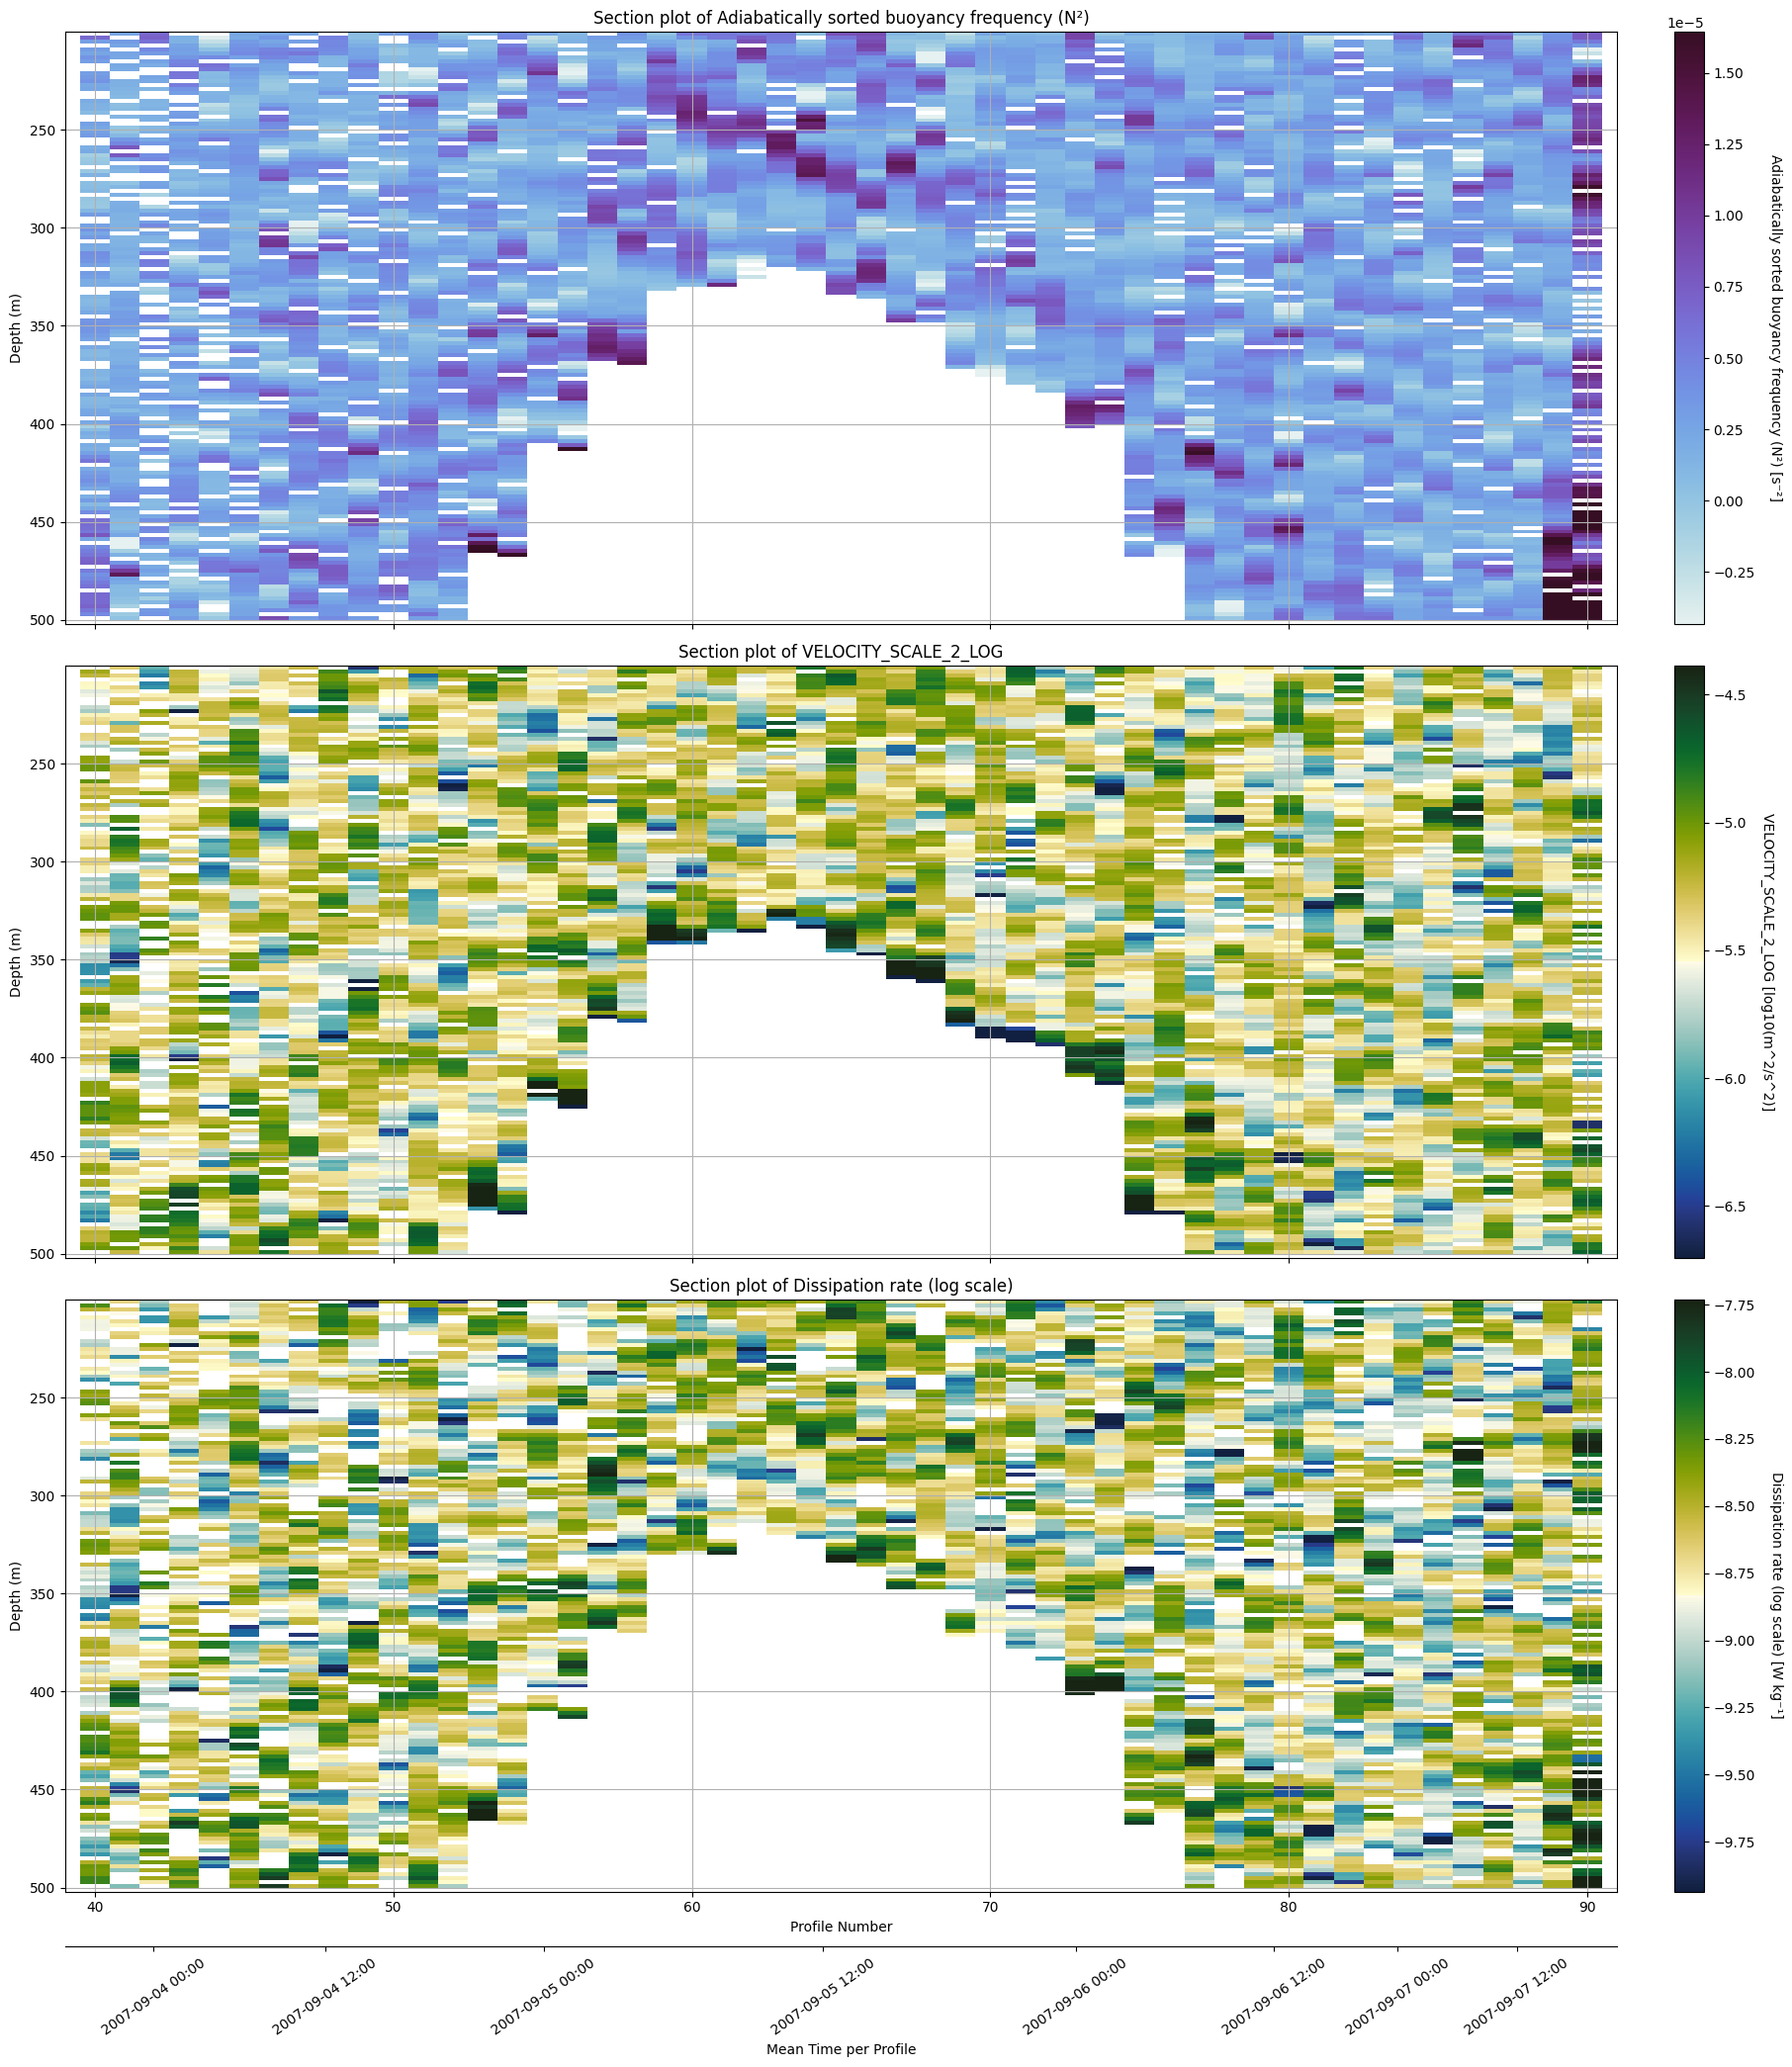

In [184]:
importlib.reload(plotting)
mean_ratio, median_ratio, ratio_total = get_background_dissipation(ds_binned, profile_range=profile_range, depth_range=depth_range, sg005_ds=sg005_ds)

In [113]:
### delete values from DISSIPATION_LEM that are below threshold 
threshold = 1e-10
ds_binned['DISSIPATION_LEM'] = ds_binned['DISSIPATION_LEM'].where(ds_binned['DISSIPATION_LEM'] > threshold, np.nan)
ds_binned['DISSIPATION_LEM_LOG'] = np.log10(ds_binned['DISSIPATION_LEM'])

In [114]:
### cut the profiles from 760 onwards if Glider is 101 and Mission is '20070609'
if ds_binned.Glider == '101' and ds_binned.Mission == '20070609':
    ds_binned = ds_binned.where(ds_binned.PROFILE_NUMBER < 760, drop=True)
    print('Cutting profiles from 760 onwards for Glider 101 and Mission 20070609')

### 2.X Save the binned data with dissipation information as dissipation_binned.nc

In [115]:
### save the ds_binned dataset

#ds_binned.to_netcdf(mission_path + '/dissipation_binned.nc')


In [201]:
ds_binned = xr.open_dataset(mission_path + '/dissipation_binned.nc')

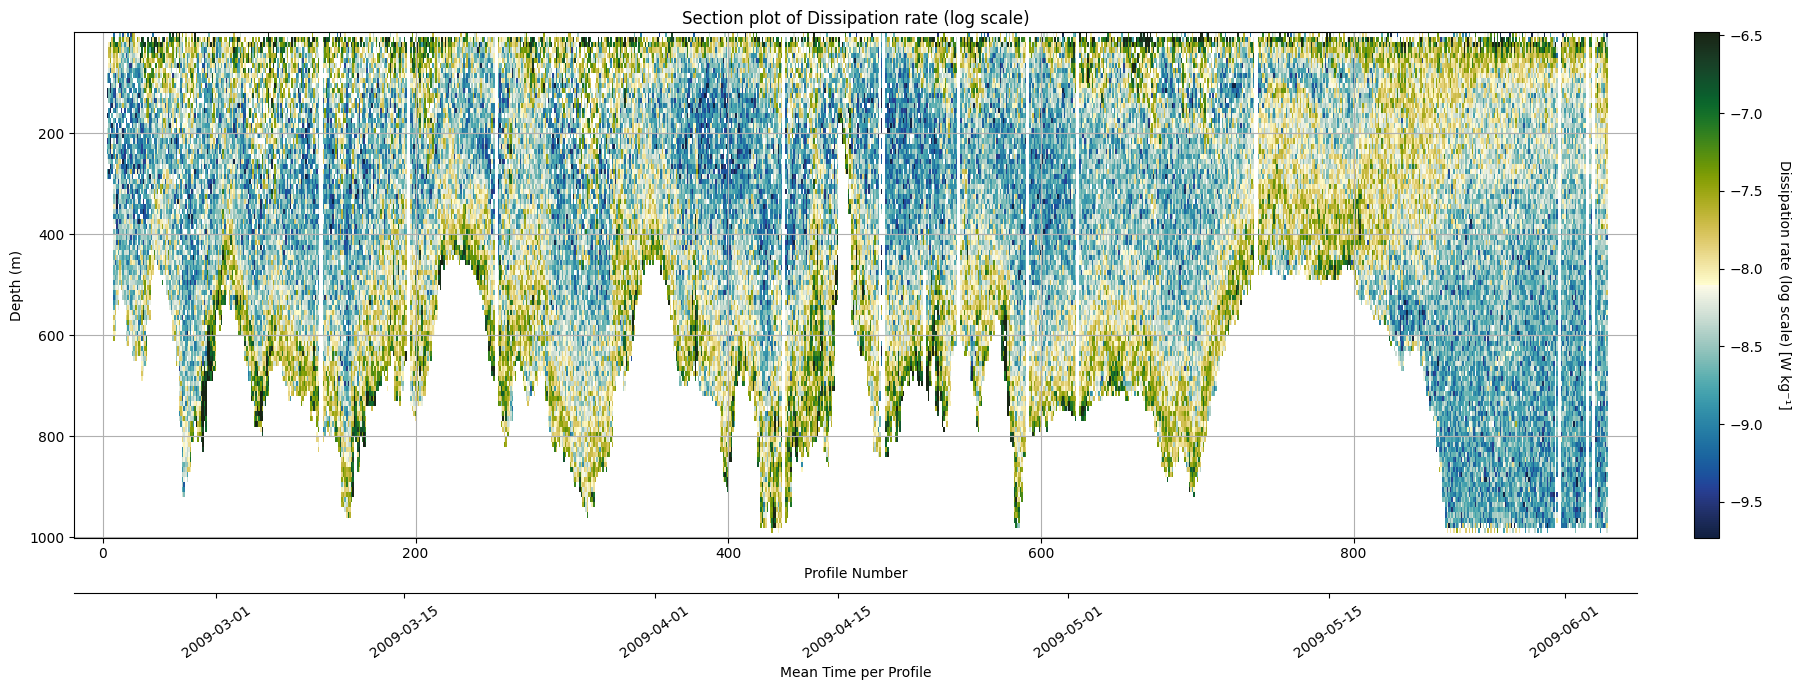

In [203]:
fig, axs = plotting.plot_section(ds_binned, vars=['DISSIPATION_LEM_LOG'], v_res=10, start=start, end=end)

In [134]:
#interactive.interactive_profile(ds)

### 3. Load ERA-5 data and compare to dissipation data 

In [135]:
ERA5_basepath = '/Users/tillmoritz/Desktop/Master_thesis/Data/ERA-5/'
ds_ERA5 = xr.open_dataset(ERA5_basepath + '/ERA5_all_winds_fluxes_waves.nc')

In [66]:
def add_epsilon_tau(ds, mld_ds):
    ds = ds.copy()
    epsilon_tau_z_all = []
    for i in tqdm(range(len(mld_ds['PROFILE_NUMBER']))):
        profile_number = mld_ds['PROFILE_NUMBER'].values[i]
        mld_depth = mld_ds['MLD'].values[i]
        tau = mld_ds['TAU'].values[i]
        rho = mld_ds['SIGTHETA_MEAN'].values[i]
        u_star = np.sqrt(tau/rho)

        # Extract variable and depth for current profile
        profile_mask = ds['PROFILE_NUMBER'] == profile_number
        profile = ds.where(profile_mask, drop=True)

        binned_depth = profile.DEPTH.values

        if np.isnan(mld_depth):
            epsilon_tau_z = np.full_like(binned_depth, np.nan)
            epsilon_tau_z_all.append(epsilon_tau_z)
            continue

        epsilon_tau_z = u_star**3/(0.4*binned_depth)
        epsilon_tau_z_all.append(epsilon_tau_z)
    epsilon_tau_z_all = np.concatenate(epsilon_tau_z_all)
    ds['EPSILON_TAU_Z'] = ('TIME', epsilon_tau_z_all)
    return ds

        

In [71]:
ds_binned = add_epsilon_tau(ds_binned,mld_ds)

100%|██████████| 770/770 [00:08<00:00, 93.28it/s] 


In [69]:
interactive.interactive_profile(epsilon_tau_z_all)

Output()

### 4. Finish the dissipation calculation

In [148]:
mld_ds = tools.mean_in_mld(ds, mld_ds, ['SIGTHETA','PSAL','TEMP'])

Computing mean for SIGTHETA in MLD


100%|██████████| 906/906 [00:13<00:00, 66.14it/s]


Computing mean for PSAL in MLD


100%|██████████| 906/906 [00:13<00:00, 67.91it/s]


Computing mean for TEMP in MLD


100%|██████████| 906/906 [00:13<00:00, 66.57it/s]


In [149]:
importlib.reload(tools)
mld_ds = tools.match_era5_to_mld(mld_ds, ds_ERA5,lon_range=0.25,lat_range=0.25,time_lag = None, time_range=None)

Matching ERA5 to MLD: 100%|██████████| 906/906 [00:05<00:00, 181.04it/s]


In [150]:
mld_ds = tools.add_hs(mld_ds)

In [151]:
importlib.reload(tools)
H_S = mld_ds['H_S'].values
mld_ds = tools.integrate_in_mld(ds_binned, mld_ds, ['DISSIPATION_LEM'],min_depth=H_S)
#mld_ds = tools.integrate_in_mld(ds_binned, mld_ds, ['EPSILON_TAU_Z'], min_depth=mld_ds.DISSIPATION_LEM_MIN_DEPTH, max_depth=mld_ds.DISSIPATION_LEM_MAX_DEPTH)

Calculating integral for DISSIPATION_LEM...


100%|██████████| 906/906 [00:12<00:00, 72.14it/s]


fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(nrows=2,ncols=2,figsize= [10,6])
mld_ds['DISSIPATION_LEM_TOTAL'].plot(ax = ax1)
mld_ds['EPSILON_TAU_Z_TOTAL'].plot(ax = ax3)
mld_ds['EPSILON_TAU'].plot(ax = ax4)
plt.show()

In [152]:
importlib.reload(tools)
mld_ds = tools.dissipation_bouyancy_flux(mld_ds)
mld_ds = tools.dissipation_wind_stress(mld_ds)

<xarray.DataArray 'DISSIPATION_LEM_MIN_DEPTH' (TIME: 906)> Size: 7kB
array([        nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan, 27.17402483,
       24.5410408 , 22.89357202,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan, 33.57947874,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan, 12.65472067, 20.50181977,
               nan,         nan, 26.82418802, 30.60757316, 22.07265674,
               nan, 27.85351279, 29.98199403,         nan,         nan,
       30.15215454,         nan, 49.88914545, 48.41515262,         nan,
               nan,         nan,         nan,         nan,         

In [154]:
#### save the mld_ds dataset
mld_ds.to_netcdf(mission_path + '/dissipation_mld.nc')

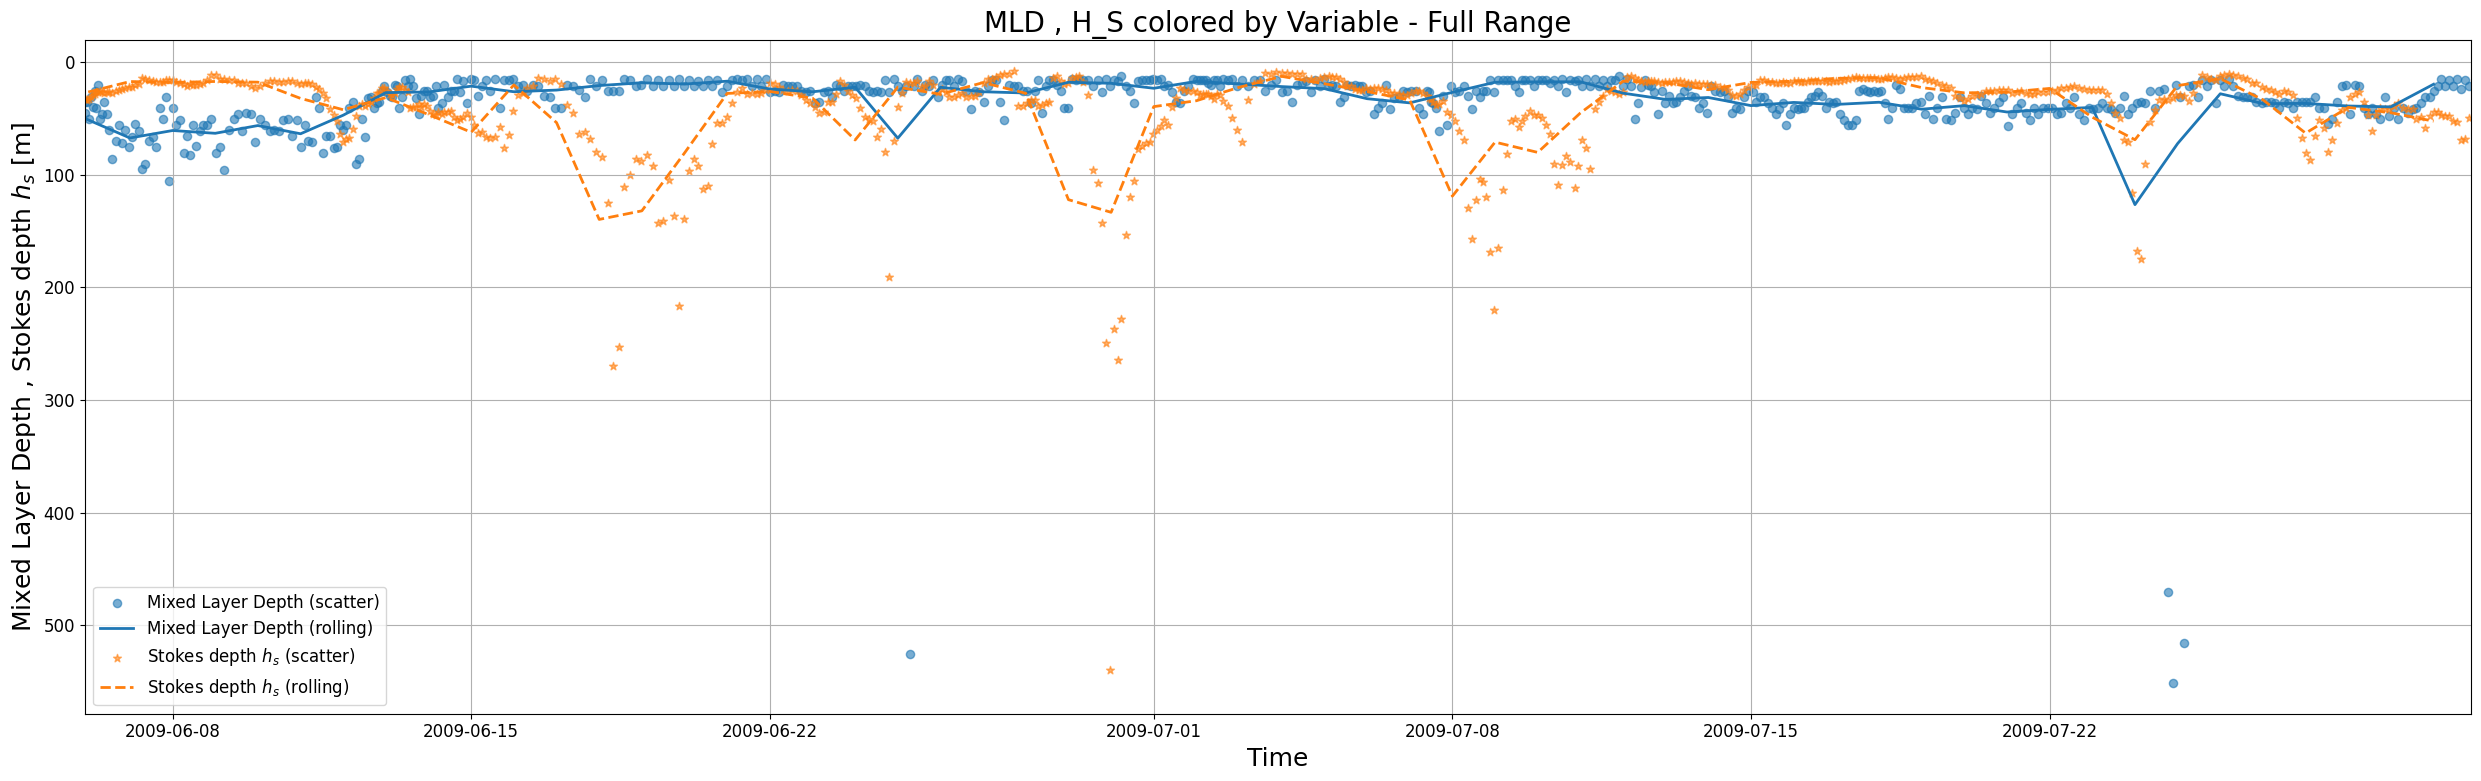

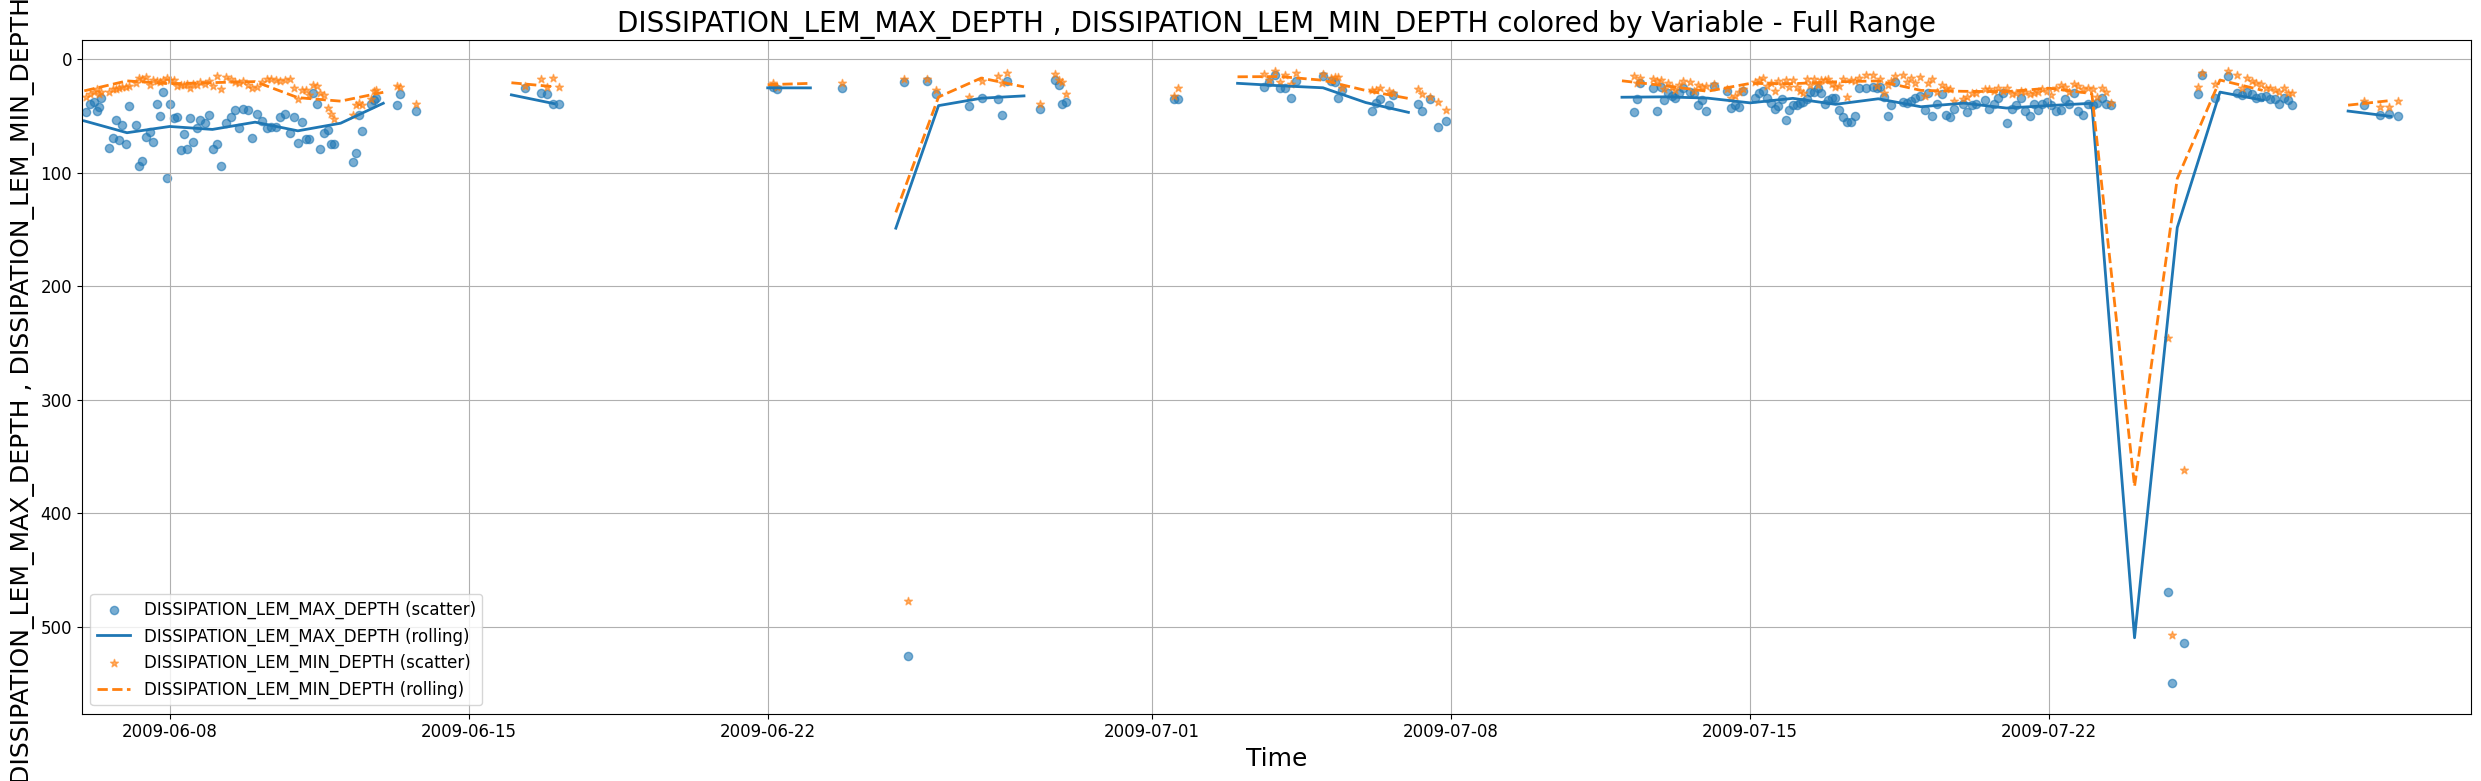

In [124]:
importlib.reload(plotting)
fig, axes = plotting.plot_var_from_mld(mld_ds, vars = ['MLD','H_S'], rolling_str='1D',years = None, plot_type="both", mission_cbar=False, one_plot=True)
[ax.invert_yaxis() for ax in axes]
fig, axes = plotting.plot_var_from_mld(mld_ds, vars = ['DISSIPATION_LEM_MAX_DEPTH','DISSIPATION_LEM_MIN_DEPTH'], rolling_str='1D',years = None, plot_type="both", mission_cbar=False, one_plot=True)
[ax.invert_yaxis() for ax in axes]
plt.show()

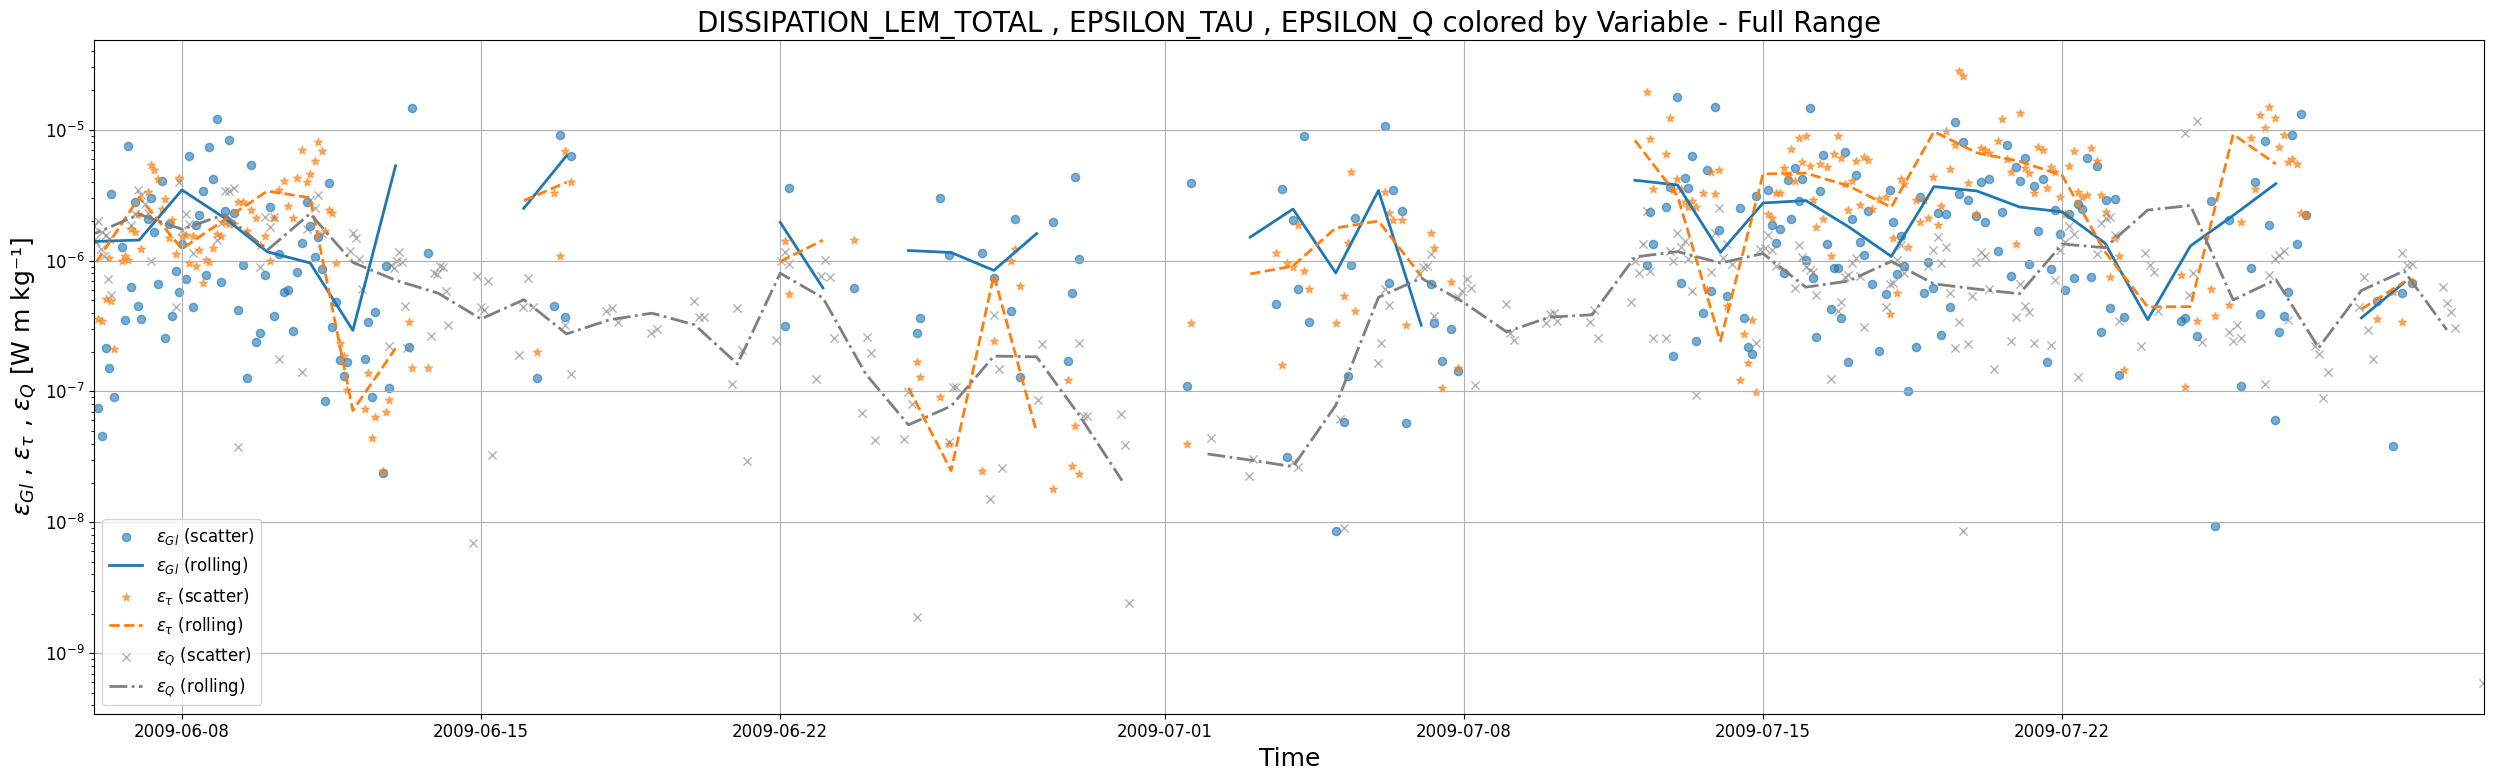

In [125]:
fig, axes = plotting.plot_var_from_mld(mld_ds, vars = ['DISSIPATION_LEM_TOTAL','EPSILON_TAU','EPSILON_Q'], rolling_str='1D',years = None, plot_type="both", mission_cbar=False, one_plot=True)
### make y-axis logarithmic
[ax.set_yscale('log') for ax in axes]
fig.savefig(mission_path + '/dissipation_LEM_total_EPSILON_TAU.png', dpi=300, bbox_inches='tight')
plt.show()

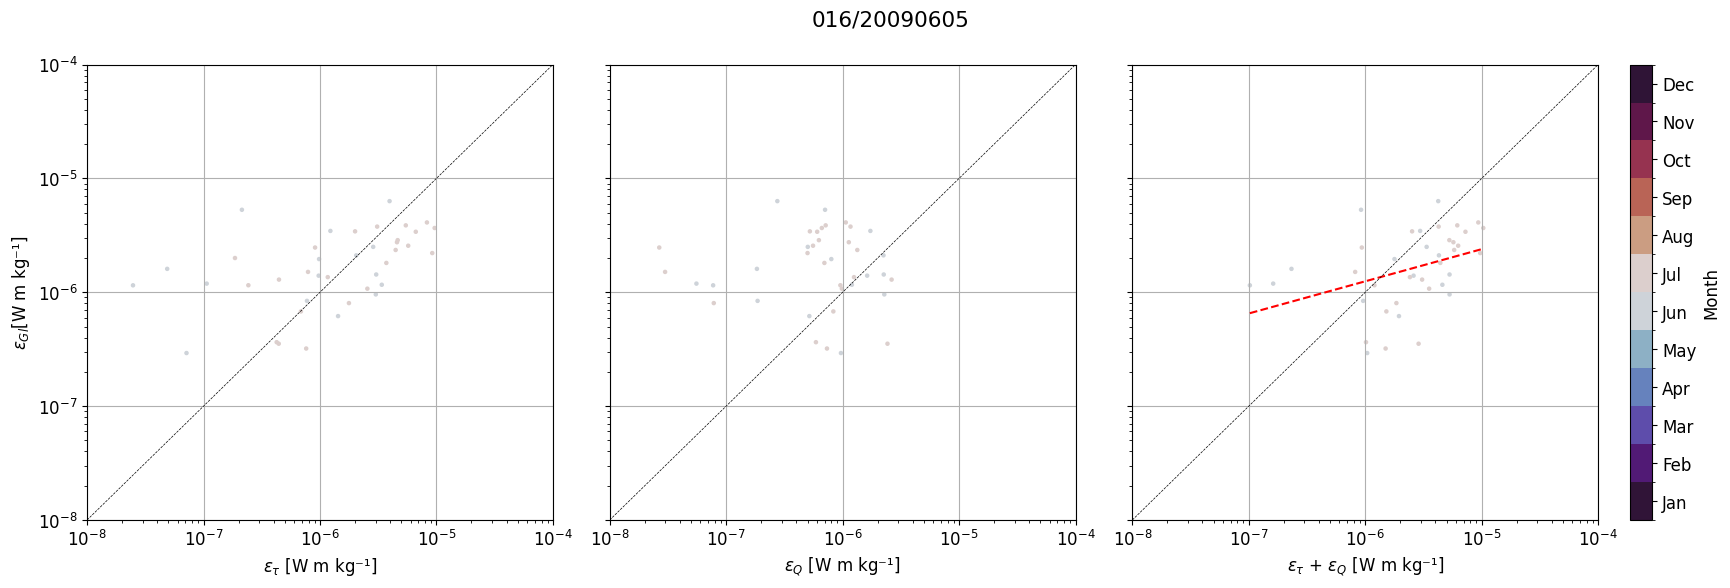

In [126]:
importlib.reload(plotting)
fig, ax = plotting.plot_dissipation_scatter(mld_ds, rolling_str="1d", color_by='TIME')
fig.savefig(mission_path + '/dissipation_scatter.png', dpi=300, bbox_inches='tight')